In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from textblob import TextBlob

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [8]:
apps = pd.read_csv(r"C:\Users\navee\Documents\Dataset\googleplaystore.csv")
reviews = pd.read_csv(r"C:\Users\navee\Documents\Dataset\googleplaystore_user_reviews.csv")

In [9]:
print("Apps Dataset Shape:", apps.shape)
print("Reviews Dataset Shape:", reviews.shape)

Apps Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)


In [10]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [11]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [12]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [13]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [14]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [15]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [16]:
print("Before:", apps.shape)

apps.drop_duplicates(inplace=True)

print("After:", apps.shape)

Before: (10841, 13)
After: (10358, 13)


In [17]:
apps = apps.dropna(subset=["Rating"])

In [18]:
apps = apps.dropna(subset=[
    "Type",
    "Content Rating",
    "Current Ver",
    "Android Ver"
])

In [19]:
reviews = reviews.dropna()

In [20]:
reviews.isnull().sum()

App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [21]:
apps[~apps["Reviews"].astype(str).str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [24]:
apps["Reviews"].astype(int)

0           159
1           967
2         87510
3        215644
4           967
          ...  
10834         7
10836        38
10837         4
10839       114
10840    398307
Name: Reviews, Length: 8886, dtype: int64

In [25]:
apps["Reviews"] = apps["Reviews"].astype(int)

In [26]:
apps["Installs"] = (
    apps["Installs"]
    .str.replace(",", "")
    .str.replace("+", "", regex=False)
)

apps["Installs"] = apps["Installs"].astype(int)

In [27]:
apps["Installs"].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [28]:
apps["Price"] = (
    apps["Price"]
    .str.replace("$", "", regex=False)
)

apps["Price"] = apps["Price"].astype(float)

In [29]:
apps["Price"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [30]:
import numpy as np

def clean_size(size):
    if size == "Varies with device":
        return np.nan
    elif "M" in size:
        return float(size.replace("M", ""))
    elif "k" in size:
        return float(size.replace("k", "")) / 1024
    else:
        return np.nan

apps["Size"] = apps["Size"].apply(clean_size)
apps["Size"] = apps["Size"].fillna(apps["Size"].median())

In [31]:
apps["Size"].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [32]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8886 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8886 non-null   object 
 1   Category        8886 non-null   object 
 2   Rating          8886 non-null   float64
 3   Reviews         8886 non-null   int64  
 4   Size            8886 non-null   float64
 5   Installs        8886 non-null   int64  
 6   Type            8886 non-null   object 
 7   Price           8886 non-null   float64
 8   Content Rating  8886 non-null   object 
 9   Genres          8886 non-null   object 
 10  Last Updated    8886 non-null   object 
 11  Current Ver     8886 non-null   object 
 12  Android Ver     8886 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 971.9+ KB


In [33]:
category_counts = apps["Category"].value_counts()

category_counts

Category
FAMILY                 1717
GAME                   1074
TOOLS                   733
PRODUCTIVITY            334
FINANCE                 317
PERSONALIZATION         308
COMMUNICATION           307
LIFESTYLE               305
PHOTOGRAPHY             304
MEDICAL                 302
SPORTS                  286
BUSINESS                270
HEALTH_AND_FITNESS      262
SOCIAL                  244
NEWS_AND_MAGAZINES      214
TRAVEL_AND_LOCAL        205
SHOPPING                202
BOOKS_AND_REFERENCE     177
VIDEO_PLAYERS           160
DATING                  159
EDUCATION               129
MAPS_AND_NAVIGATION     124
ENTERTAINMENT           111
FOOD_AND_DRINK          106
WEATHER                  75
AUTO_AND_VEHICLES        73
HOUSE_AND_HOME           68
LIBRARIES_AND_DEMO       64
ART_AND_DESIGN           61
COMICS                   58
PARENTING                50
EVENTS                   45
BEAUTY                   42
Name: count, dtype: int64

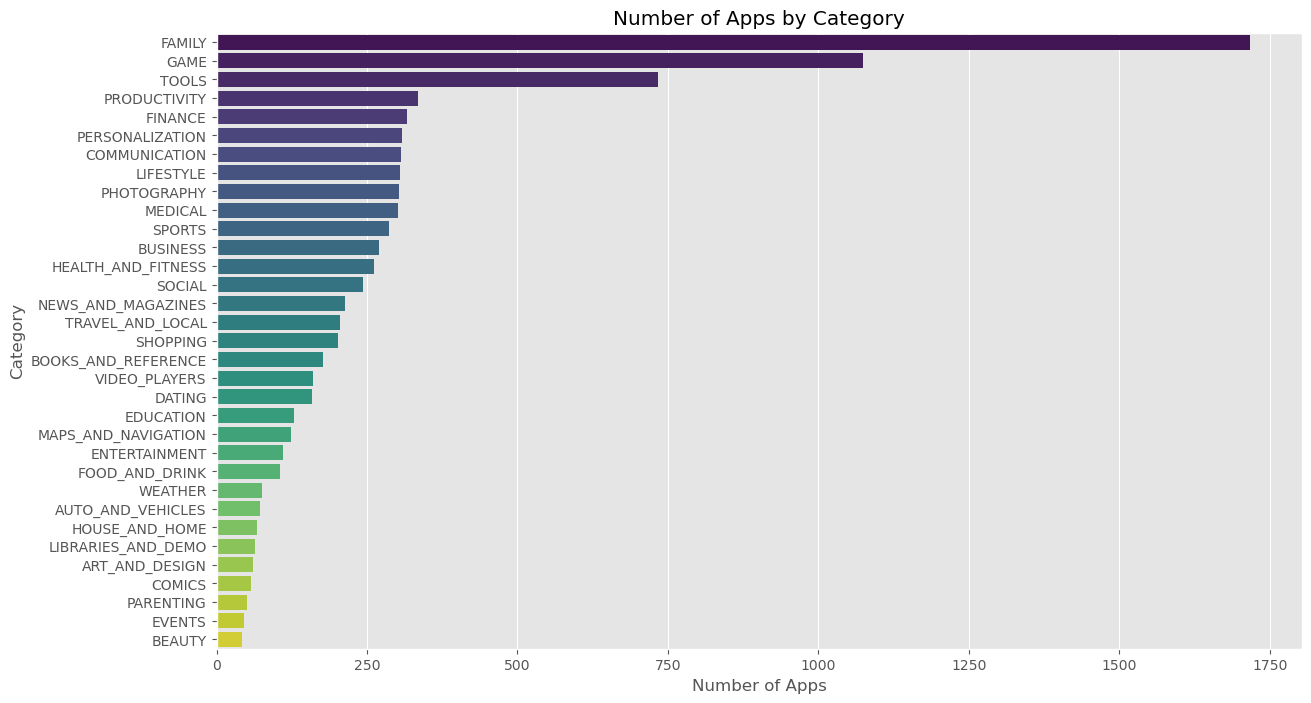

In [34]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    palette="viridis"
)

plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.show()

In [35]:
print(category_counts.head(10))

Category
FAMILY             1717
GAME               1074
TOOLS               733
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     308
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64


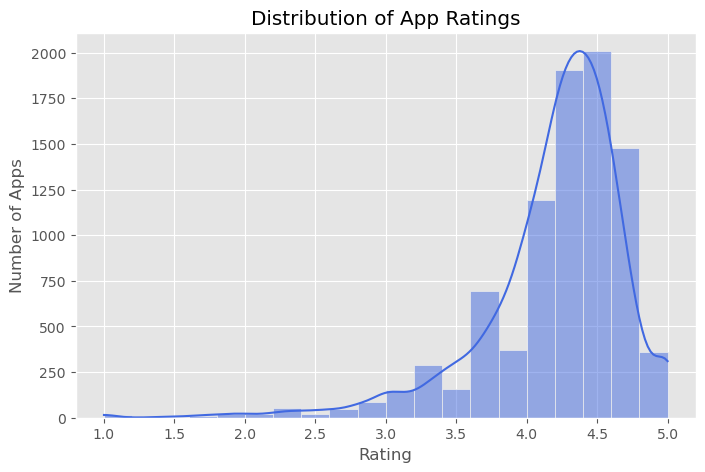

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps["Rating"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

In [37]:
avg_rating = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)

avg_rating

Category
EVENTS                 4.435556
ART_AND_DESIGN         4.377049
EDUCATION              4.375969
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333117
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
SHOPPING               4.251485
WEATHER                4.244000
SPORTS                 4.225175
PRODUCTIVITY           4.201796
FAMILY                 4.191264
AUTO_AND_VEHICLES      4.190411
PHOTOGRAPHY            4.182895
MEDICAL                4.182450
LIBRARIES_AND_DEMO     4.179688
HOUSE_AND_HOME         4.164706
FOOD_AND_DRINK         4.164151
COMICS                 4.155172
COMMUNICATION          4.151466
ENTERTAINMENT          4.136036
NEWS_AND_MAGAZINES     4.128505
FINANCE                4.127445
BUSINESS               4.102593
LIFESTYLE              4.096066
TRAVEL_AND_LOCAL       4.094146
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613

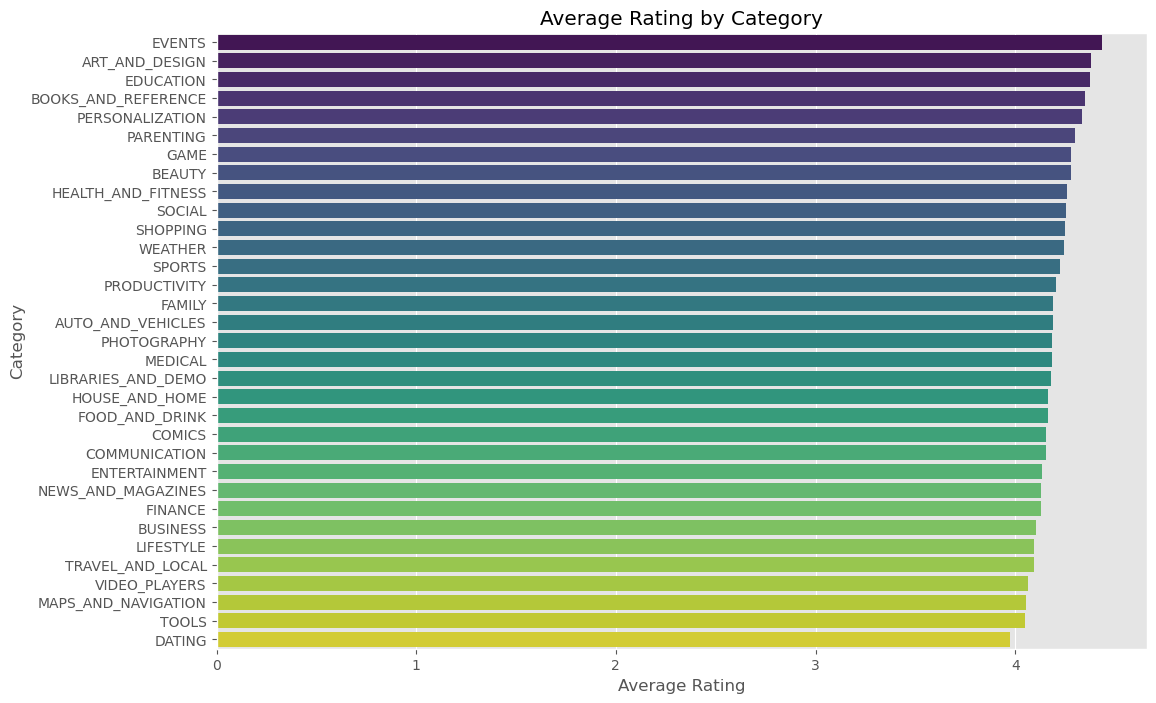

In [38]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index,
    palette="viridis"
)

plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.show()

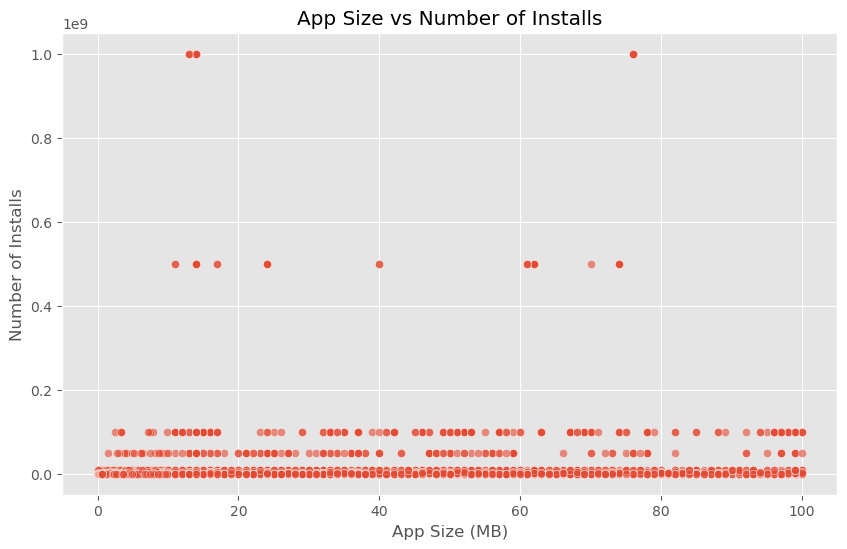

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x="Size",
    y="Installs",
    alpha=0.6
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.show()

In [40]:
correlation = apps["Size"].corr(apps["Installs"])

print("Correlation between Size and Installs:", correlation)

Correlation between Size and Installs: 0.046979544022793564


In [41]:
apps["Type"].value_counts()

Type
Free    8275
Paid     611
Name: count, dtype: int64

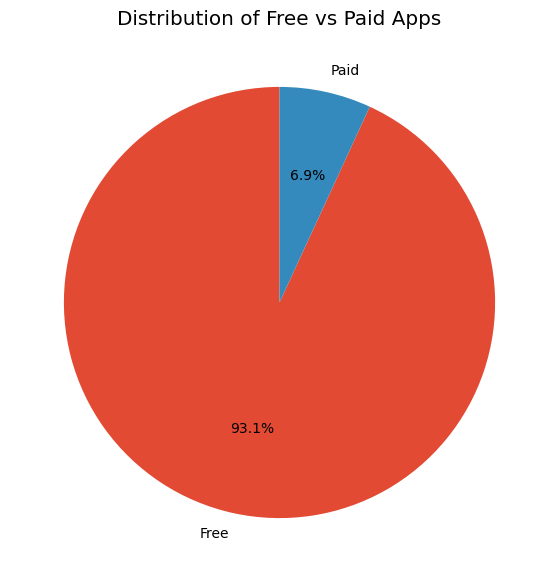

In [42]:
plt.figure(figsize=(7,7))

apps["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Free vs Paid Apps")
plt.ylabel("")

plt.show()

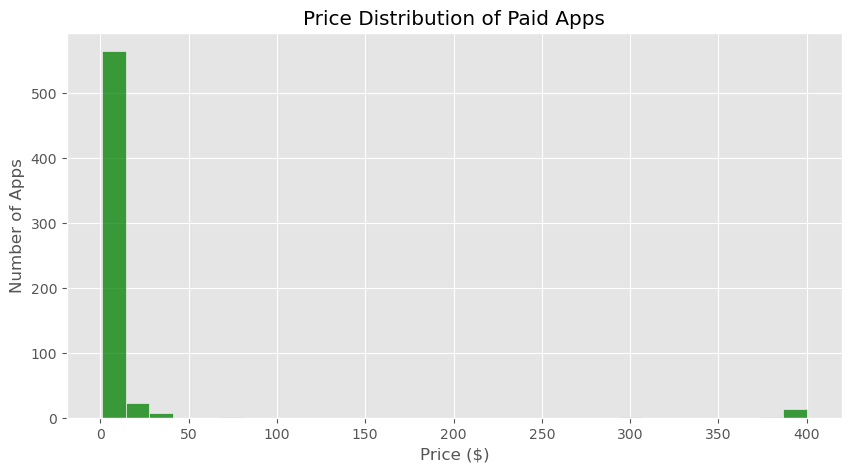

In [43]:
paid_apps = apps[apps["Type"] == "Paid"]

plt.figure(figsize=(10,5))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    color="green"
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.show()

In [44]:
apps["Estimated Revenue"] = apps["Installs"] * apps["Price"]

In [45]:
revenue = (
    apps.groupby("Category")["Estimated Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue.head(10)

Category
FAMILY             1.857248e+08
LIFESTYLE          5.758394e+07
GAME               4.098684e+07
FINANCE            2.572664e+07
PHOTOGRAPHY        8.941050e+06
MEDICAL            8.371355e+06
PERSONALIZATION    7.784820e+06
TOOLS              5.462910e+06
SPORTS             4.706154e+06
PRODUCTIVITY       4.304452e+06
Name: Estimated Revenue, dtype: float64

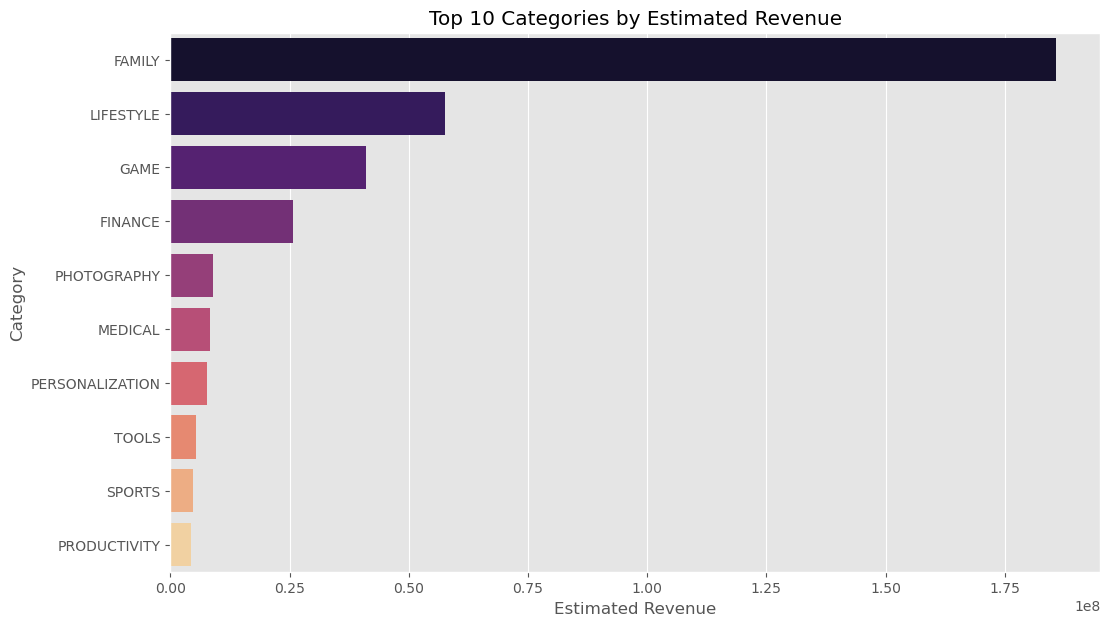

In [46]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=revenue.values[:10],
    y=revenue.index[:10],
    palette="magma"
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue")
plt.ylabel("Category")

plt.show()

In [49]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


In [50]:
from textblob import TextBlob

def get_sentiment(review):
    if pd.isna(review):
        return "Neutral"

    polarity = TextBlob(review).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

reviews["Predicted_Sentiment"] = reviews["Translated_Review"].apply(get_sentiment)

In [51]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Predicted_Sentiment
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,Positive
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,Positive
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,Positive
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,Positive
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,Positive


In [52]:
reviews["Predicted_Sentiment"].value_counts()

Predicted_Sentiment
Positive    23997
Negative     8272
Neutral      5158
Name: count, dtype: int64

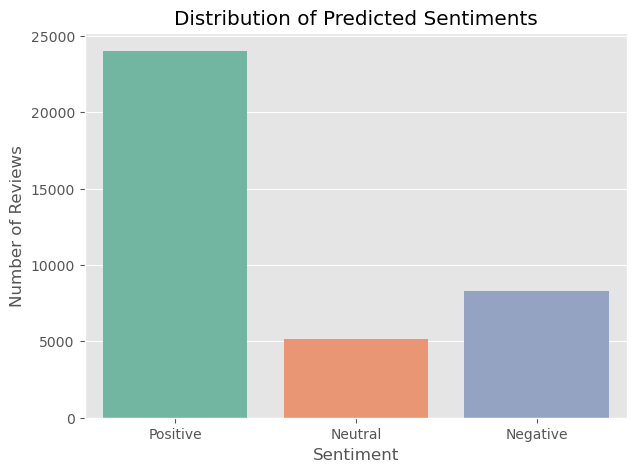

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=reviews,
    x="Predicted_Sentiment",
    palette="Set2"
)

plt.title("Distribution of Predicted Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [54]:
merged = pd.merge(
    reviews,
    apps[["App", "Category"]],
    on="App",
    how="inner"
)

In [55]:
merged.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Predicted_Sentiment,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,Positive,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,Positive,HEALTH_AND_FITNESS
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,Positive,HEALTH_AND_FITNESS
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,Positive,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best way,Positive,1.00,0.300000,Positive,HEALTH_AND_FITNESS


In [56]:
positive = (
    merged[merged["Predicted_Sentiment"] == "Positive"]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

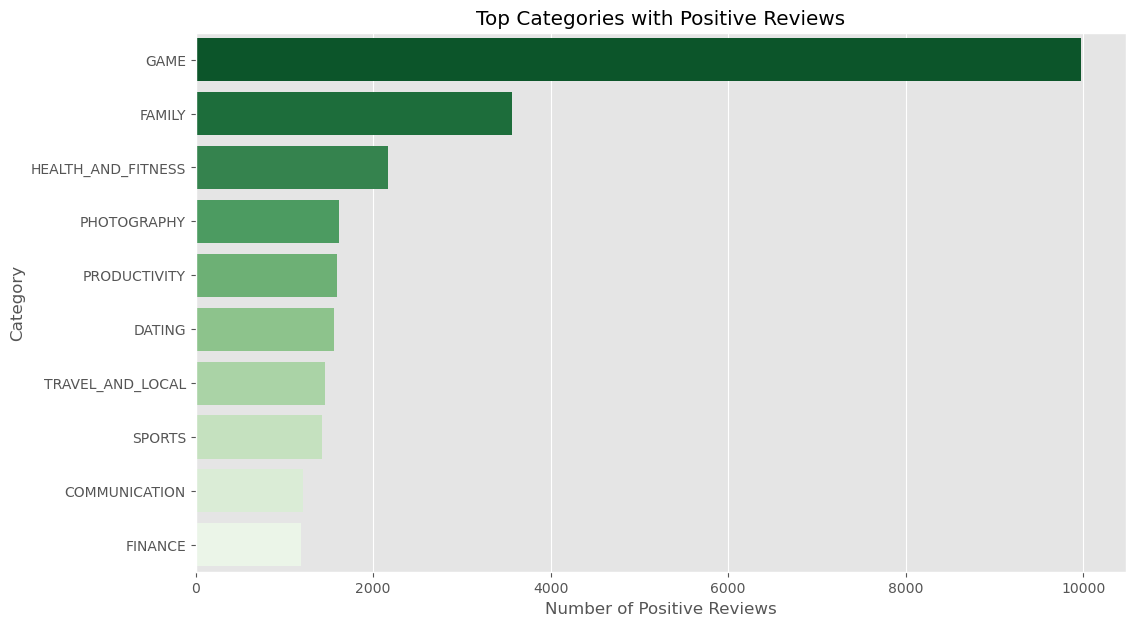

In [57]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=positive.values[:10],
    y=positive.index[:10],
    palette="Greens_r"
)

plt.title("Top Categories with Positive Reviews")
plt.xlabel("Number of Positive Reviews")
plt.ylabel("Category")

plt.show()

In [58]:
import plotly.express as px

In [59]:
category_counts = (
    apps["Category"]
    .value_counts()
    .head(10)
    .reset_index()
)

category_counts.columns = ["Category", "Count"]

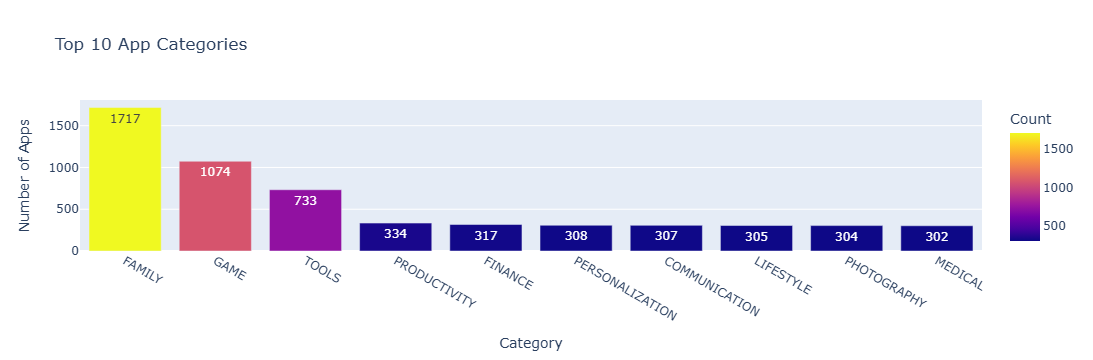

In [61]:
fig = px.bar(
    category_counts,
    x="Category",
    y="Count",
    color="Count",
    title="Top 10 App Categories",
    text="Count"
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Number of Apps"
)

fig.show()

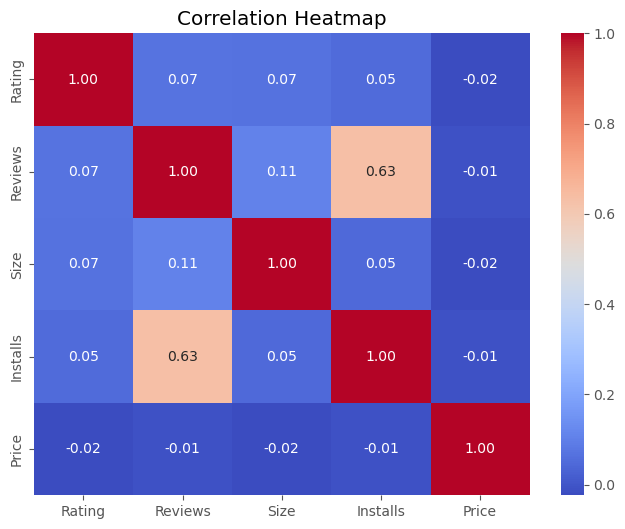

In [62]:
plt.figure(figsize=(8,6))

sns.heatmap(
    apps[["Rating", "Reviews", "Size", "Installs", "Price"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()